In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [97]:
data= pd.read_csv('../artifects/sentiment_analysis.csv')

In [98]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


## Data Preprocessing

In [99]:
data.shape

(7920, 3)

In [100]:
data.duplicated().sum()

np.int64(0)

In [101]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

## Text Preprocessing

In [102]:
#covert uppercase to lawer case
#Remove links
#Remove punctuations
#Remove Numbers
#Remove stopwords
#stemming

In [103]:
import re
import string

In [104]:
data ["tweet"].head(5)

0    #fingerprint #Pregnancy Test https://goo.gl/h1...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
Name: tweet, dtype: object

## convert uppercase to lawercase

In [105]:
data["tweet"] = data["tweet"].apply(lambda x:" " .join(x.lower() for x in x.split()))

## x → one tweet (string)
## x.split() → splits sentence into words
#3word.lower() → converts each word to lowercase
##" ".join(...) → joins words back into a sentence

In [106]:
data ["tweet"].head(5)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: object

## Remove links

In [107]:
data["tweet"] = data["tweet"].apply(lambda x:" " .join(re.sub (r'^https?:/\/\.*[\r\n]*' , '', x , flags=re.MULTILINE) for x in x.split()))

In [108]:
data ["tweet"].head(5)

0    #fingerprint #pregnancy test goo.gl/h1mfqv #an...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
Name: tweet, dtype: object

## Remove Punctuations

In [109]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [110]:
def remove_punctuations(text):
    for punctuation in string .punctuation:
        text = text.replace(punctuation, '')
    return text
data["tweet"] = data["tweet"].apply (remove_punctuations)

In [111]:
data ["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911    i am completely in love with the new iphone em...
7912    tune in turn on drop out  gtd in one app bitly...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely 90 year old neighbor with he...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

## Remove Number

In [112]:
data["tweet"] = data["tweet"].str.replace('\d+','',regex=True)

In [113]:
data ["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911    i am completely in love with the new iphone em...
7912    tune in turn on drop out  gtd in one app bitly...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely  year old neighbor with her ...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

## Remove stop words

In [114]:
!pip install nltk

In [115]:
import nltk

In [116]:
nltk.download('stopwords', download_dir ='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [117]:
with open ('../static/model/corpora/stopwords/english','r') as file:
    sw = file.read().splitlines()
    

In [118]:
##stop words
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [119]:
data["tweet"] = data["tweet"].apply(lambda x:" " .join (x for x in x.split() if x not in sw))

In [120]:
data ["tweet"].head()

0    fingerprint pregnancy test googlhmfqv android ...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
Name: tweet, dtype: object

## Stemming

In [121]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [122]:
data["tweet"] = data["tweet"].apply(lambda x:" " .join (ps.stem (x) for x in x.split()))

In [123]:
data ["tweet"].head(5)

0    fingerprint pregnanc test googlhmfqv android a...
1    final transpar silicon case thank uncl yay son...
2    love would go talk makememori unplug relax iph...
3    im wire know im georg made way iphon cute dave...
4    amaz servic appl wont even talk question unles...
Name: tweet, dtype: object

In [124]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test googlhmfqv android a...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


## Building Vocabulary

In [125]:
from collections import Counter
vocab= Counter()

In [126]:
vocab.update(['Java','Python','C++','JS'])

In [127]:
vocab

Counter({'Java': 1, 'Python': 1, 'C++': 1, 'JS': 1})

In [128]:
for sentence in data ["tweet"]:
    vocab.update(sentence.split())

In [129]:
vocab

Counter({'iphon': 4073,
         'appl': 2876,
         'samsung': 1395,
         'new': 1137,
         'phone': 1015,
         'follow': 885,
         'soni': 819,
         '…': 751,
         'ipad': 537,
         'rt': 525,
         'love': 499,
         'like': 455,
         'day': 426,
         'app': 416,
         'life': 415,
         'android': 414,
         'photo': 394,
         'get': 382,
         'io': 382,
         'galaxi': 361,
         'instagram': 358,
         'case': 348,
         'beauti': 322,
         'cute': 322,
         'gain': 311,
         'today': 309,
         'work': 306,
         'im': 294,
         'back': 294,
         'fuck': 293,
         'happi': 293,
         'photographi': 292,
         'game': 282,
         'got': 280,
         'fun': 277,
         'news': 265,
         'thank': 263,
         'music': 263,
         'time': 248,
         'make': 247,
         'updat': 236,
         'smile': 231,
         'instagood': 226,
         'funni': 223,
   

In [130]:
len(vocab)

19985

In [131]:
data.shape

(7920, 3)

In [132]:
tokens=[key for key in vocab if vocab[key]>10]

In [133]:
tokens

['test',
 'android',
 'app',
 'beauti',
 'cute',
 'health',
 'iger',
 'iphoneonli',
 'iphonesia',
 'iphon',
 'final',
 'case',
 'thank',
 'yay',
 'soni',
 'xperia',
 'love',
 'would',
 'go',
 'talk',
 'relax',
 'smartphon',
 'wifi',
 'connect',
 'im',
 'know',
 'made',
 'way',
 'home',
 'amaz',
 'servic',
 'appl',
 'wont',
 'even',
 'question',
 'pay',
 'stupid',
 'support',
 'softwar',
 'updat',
 'fuck',
 'phone',
 'big',
 'time',
 'happi',
 'us',
 'instap',
 'instadaili',
 'xperiaz',
 'new',
 'type',
 'c',
 'charger',
 'cabl',
 'uk',
 '…',
 'amazon',
 'year',
 'newyear',
 'start',
 'technolog',
 'samsunggalaxi',
 'iphonex',
 'shop',
 'listen',
 'music',
 'likeforlik',
 'photo',
 'fun',
 'selfi',
 'water',
 'camera',
 'picoftheday',
 'sun',
 'instagood',
 'boy',
 'outdoor',
 'hey',
 'make',
 'ipod',
 'dont',
 'color',
 'inch',
 'crash',
 'everi',
 'need',
 'realli',
 'drop',
 'ball',
 'design',
 'give',
 'anoth',
 'crazi',
 'purchas',
 'lol',
 'work',
 'hard',
 'play',
 'ipad',
 'batt

In [134]:
def save_vocabulary(lines,filename):
    data='\n'.join(lines)
    file=open(filename, 'w', encoding ="utf-8")
    file.write(data)
    file.close()
    
save_vocabulary(tokens,'../static/model/vocabulary.text')

In [135]:
## we have train and test the data model


In [136]:
data

,id,label,tweet
0,1,0,fingerprint pregnanc test googlhmfqv android a...
1,2,0,final transpar silicon case thank uncl yay son...
2,3,0,love would go talk makememori unplug relax iph...
3,4,0,im wire know im georg made way iphon cute dave...
4,5,1,amaz servic appl wont even talk question unles...
...,...,...,...
7915,7916,0,live loud lol liveoutloud selfi smile soni mus...
7916,7917,0,would like wish amaz day make everi minut coun...
7917,7918,0,help love year old neighbor ipad morn made rea...
7918,7919,0,final got smart pocket wifi stay connect anyti...


In [137]:
len (tokens)

1154

In [138]:
data.shape

(7920, 3)

## Divide Dataset

In [139]:
x = data['tweet']
y = data['label']

In [140]:
y

0       0
1       0
2       0
3       0
4       1
       ..
7915    0
7916    0
7917    0
7918    0
7919    0
Name: label, Length: 7920, dtype: int64

In [141]:
x

0       fingerprint pregnanc test googlhmfqv android a...
1       final transpar silicon case thank uncl yay son...
2       love would go talk makememori unplug relax iph...
3       im wire know im georg made way iphon cute dave...
4       amaz servic appl wont even talk question unles...
                              ...                        
7915    live loud lol liveoutloud selfi smile soni mus...
7916    would like wish amaz day make everi minut coun...
7917    help love year old neighbor ipad morn made rea...
7918    final got smart pocket wifi stay connect anyti...
7919    appl barcelona appl store bcn barcelona travel...
Name: tweet, Length: 7920, dtype: object

In [142]:
!pip install scikit_learn

In [143]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2)

In [144]:
x_train.shape

(6336,)

In [145]:
x_test.shape

(1584,)

In [146]:
y_test

5309    1
5752    0
5526    1
5071    0
7468    0
       ..
6655    0
1886    0
7706    0
1645    0
3550    0
Name: label, Length: 1584, dtype: int64

In [147]:
y_train

332     0
1800    1
5400    0
4109    0
4654    0
       ..
63      0
6045    1
7507    0
270     0
4250    1
Name: label, Length: 6336, dtype: int64

In [148]:
x_train

332     photo healthi balloon survivor haha agoogl goo...
1800    jamesyblad brocklesbi still think appl custom ...
5400    need itun altern mainli music transfer purpos ...
4109    week sinc launch new app pleas help us make fo...
4654    bought new camera yesterday samsung wbf amaz o...
                              ...                        
63      gain follow rt must follow follow back follow ...
6045    appl give product oneyear warranti fail tell t...
7507    rt thatcutekid iphon kiss lip back boob beauti...
270     havent tri instagram yet here reason give whir...
4250    coqu iphon backfac dont fuck jokn fuck hisper ...
Name: tweet, Length: 6336, dtype: object

In [149]:
x_test

5309    jenniferfe u didnt get last text said plan pho...
5752    follow instagram iphoneographi iphonesia insta...
5526                                ladi bid co want burn
5071    gain follow rt must follow follow back follow ...
7468    like klip goodnight klip sleep rest tuesday be...
                              ...                        
6655    mask donald trump’s… dlvritlqlgyw news photogr...
1886    went appl pick carter mountain babe charlottes...
7706    soni xperia z unbox newphon freeupgrad soni xp...
1645    rtd term today iranelect iphon follow iran sea...
3550    babi got big brother samsung samsungtab samsun...
Name: tweet, Length: 1584, dtype: object

## Vectorization

In [150]:
def vectorizer(ds,vocabulary):
    vectorized_lst = []

    for sentence in ds:
         sentence_lst= np.zeros(len(vocabulary))

         for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
               sentence_lst[i]=1
            
         vectorized_lst.append(sentence_lst)
    vectorized_lst_new = np.asarray(vectorized_lst,dtype=np.float32)

    return vectorized_lst_new

In [151]:
vectorized_x_train = vectorizer(x_train,tokens)

In [152]:
vectorized_x_test  = vectorizer(x_test,tokens)

In [153]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6336, 1154), dtype=float32)

In [154]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1154), dtype=float32)

In [155]:
y_test

5309    1
5752    0
5526    1
5071    0
7468    0
       ..
6655    0
1886    0
7706    0
1645    0
3550    0
Name: label, Length: 1584, dtype: int64

In [156]:
y_train.value_counts()

label
0    4699
1    1637
Name: count, dtype: int64

In [157]:
## here 0 is positive and 1 is negative class. so more dataset going to positice class. so 
##data is imbalanced.


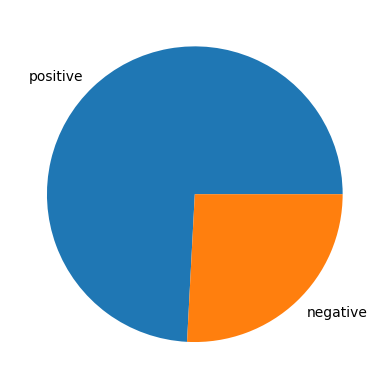

In [158]:
plt.pie(np.array([y_train.value_counts()[0],y_train.value_counts()[1]]), labels=['positive', 'negative'])
plt.show()

## Handle imbalanced Dataset

In [159]:
!pip install imbalanced-learn

In [160]:
from imblearn.over_sampling import SMOTE
smote= SMOTE()
vectorized_x_train_smote , y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)

(9398, 1154) (9398,)


In [161]:
y_train_smote.value_counts()

label
0    4699
1    4699
Name: count, dtype: int64

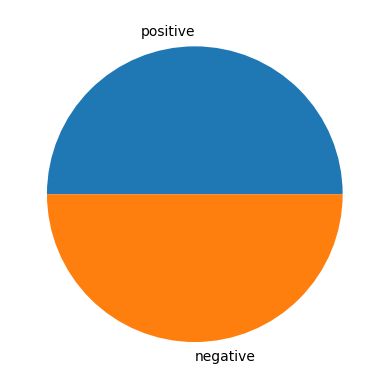

In [162]:
plt.pie(np.array([y_train_smote.value_counts()[0],y_train_smote.value_counts()[1]]), labels=['positive', 'negative'])
plt.show()

In [163]:
#train
vectorized_x_train_smote

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9398, 1154), dtype=float32)

In [164]:
#train
y_train_smote

0       0
1       1
2       0
3       0
4       0
       ..
9393    1
9394    1
9395    1
9396    1
9397    1
Name: label, Length: 9398, dtype: int64

In [165]:
#test
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 1154), dtype=float32)

In [166]:
y_test

5309    1
5752    0
5526    1
5071    0
7468    0
       ..
6655    0
1886    0
7706    0
1645    0
3550    0
Name: label, Length: 1584, dtype: int64

## Model Training and Evaluation

In [167]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [168]:
## Evaluate model
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

def training_scores(y_act,y_pred):
    acc = round(accuracy_score(y_act,y_pred),3)
    pr = round(precision_score(y_act,y_pred),3)
    rec = round(recall_score(y_act,y_pred),3)
    f1 = round(f1_score(y_act,y_pred),3)
    print (f'training scores:\n\tAccuracy = {acc}\n\tprecision = {pr}\n\tRecall = {rec}\n\tf1_score = {f1}')

def validation_scores(y_act,y_pred):
    acc = round(accuracy_score(y_act,y_pred),3)
    pr = round(precision_score(y_act,y_pred),3)
    rec = round(recall_score(y_act,y_pred),3)
    f1 = round(f1_score(y_act,y_pred),3)
    print (f'Testing scores:\n\tAccuracy = {acc}\n\tprecision = {pr}\n\tRecall = {rec}\n\tf1_score = {f1}')    
    

## Logistic Regression

In [169]:
lr = LogisticRegression()
lr.fit(vectorized_x_train_smote , y_train_smote)
y_train_pred= lr.predict(vectorized_x_train_smote)
y_train_pred
y_train_smote
training_scores(y_train_smote,y_train_pred)
y_test_pred = lr.predict(vectorized_x_test)
y_test_pred
y_test
validation_scores(y_test,y_test_pred)

training scores:
	Accuracy = 0.938
	precision = 0.917
	Recall = 0.965
	f1_score = 0.94
Testing scores:
	Accuracy = 0.879
	precision = 0.705
	Recall = 0.874
	f1_score = 0.781


## Naive_bayes - MultinomialNB

In [170]:
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote , y_train_smote)
y_train_pred= mnb.predict(vectorized_x_train_smote)
y_train_pred
y_train_smote
training_scores(y_train_smote,y_train_pred)
y_test_pred = mnb.predict(vectorized_x_test)
y_test_pred
y_test
validation_scores(y_test,y_test_pred)

training scores:
	Accuracy = 0.906
	precision = 0.87
	Recall = 0.956
	f1_score = 0.911
Testing scores:
	Accuracy = 0.866
	precision = 0.665
	Recall = 0.913
	f1_score = 0.769


## DecisionTreeClassifier

In [171]:
dt=DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote , y_train_smote)
y_train_pred= dt.predict(vectorized_x_train_smote)
y_train_pred
y_train_smote
training_scores(y_train_smote,y_train_pred)
y_test_pred = dt.predict(vectorized_x_test)
y_test_pred
y_test
validation_scores(y_test,y_test_pred)

training scores:
	Accuracy = 1.0
	precision = 1.0
	Recall = 0.999
	f1_score = 1.0
Testing scores:
	Accuracy = 0.836
	precision = 0.657
	Recall = 0.699
	f1_score = 0.677


## RandomForestClassifier

In [172]:
rf=RandomForestClassifier()
rf.fit(vectorized_x_train_smote , y_train_smote)
y_train_pred= rf.predict(vectorized_x_train_smote)
y_train_pred
y_train_smote
training_scores(y_train_smote,y_train_pred)
y_test_pred = rf.predict(vectorized_x_test)
y_test_pred
y_test
validation_scores(y_test,y_test_pred)

training scores:
	Accuracy = 1.0
	precision = 1.0
	Recall = 0.999
	f1_score = 1.0
Testing scores:
	Accuracy = 0.874
	precision = 0.751
	Recall = 0.728
	f1_score = 0.739


## SVC - Support Vector Machine

In [173]:
svm = SVC()
svm.fit(vectorized_x_train_smote , y_train_smote)
y_train_pred= svm.predict(vectorized_x_train_smote)
y_train_pred
y_train_smote
training_scores(y_train_smote,y_train_pred)
y_test_pred = svm.predict(vectorized_x_test)
y_test_pred
y_test
validation_scores(y_test,y_test_pred)

training scores:
	Accuracy = 0.979
	precision = 0.963
	Recall = 0.996
	f1_score = 0.979
Testing scores:
	Accuracy = 0.885
	precision = 0.736
	Recall = 0.83
	f1_score = 0.78


In [174]:
import pickle
with open ('../static/model/model.pickle','wb') as file:
      pickle.dump(lr,file)